In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("sample_people_income_dataset.csv")

print(df.head())

     id   name  age country  gender  income_in_rupees
0  1001    Ira   35   Nepal    Male            622845
1  1002  Ayaan   46   Nepal  Female           1690453
2  1003  Meera   49   India    Male           1140347
3  1004  Arjun   34   India  Female           1619827
4  1005  Kavya   36   Nepal    Male            382845


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   id                50 non-null     int64 
 1   name              50 non-null     object
 2   age               50 non-null     int64 
 3   country           50 non-null     object
 4   gender            50 non-null     object
 5   income_in_rupees  50 non-null     int64 
dtypes: int64(3), object(3)
memory usage: 2.5+ KB


In [5]:
df.describe()

,id,age,income_in_rupees
count,50.00000,50.000000,5.000000e+01
mean,1025.50000,37.220000,1.044777e+06
std,14.57738,8.303651,4.956389e+05
min,1001.00000,22.000000,2.869990e+05
25%,1013.25000,30.250000,6.078825e+05
50%,1025.50000,38.000000,9.421380e+05
75%,1037.75000,44.750000,1.476994e+06
max,1050.00000,50.000000,1.972107e+06


In [6]:
df.isnull().sum()

id                  0
name                0
age                 0
country             0
gender              0
income_in_rupees    0
dtype: int64

In [7]:
df.drop_duplicates(inplace=True)

In [9]:
df['age_group'] = pd.cut(
    df['age'],                                                            ## SYNTAX OF BINS: pd.cut(data, bins, labels)
    bins=[20,30,40,50],
    labels=['Young','Adult','Senior']
)

In [10]:
df['income_level'] = df['income_in_rupees'].apply(
    lambda x: 'High' if x>1000000 else 'Medium' if x>600000 else 'Low'
)

In [11]:
df['tax'] = df['income_in_rupees'] * 0.1

In [13]:
df['age'].mean()

np.float64(37.22)

In [14]:
df['income_in_rupees'].mean()

np.float64(1044776.72)

In [15]:
print(df.groupby('gender')['income_in_rupees'].mean())

gender
Female    1.034967e+06
Male      1.052484e+06
Name: income_in_rupees, dtype: float64


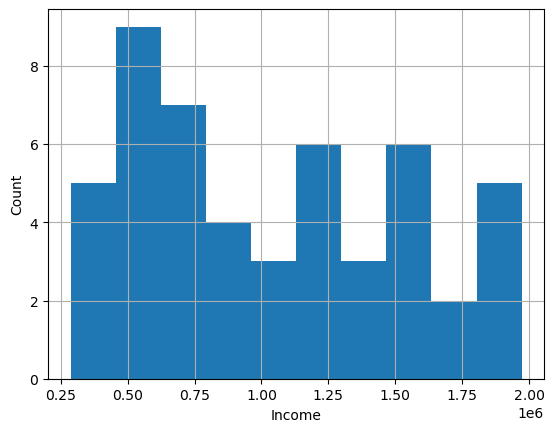

In [16]:
df['income_in_rupees'].hist()
plt.xlabel("Income")
plt.ylabel("Count")
plt.show()

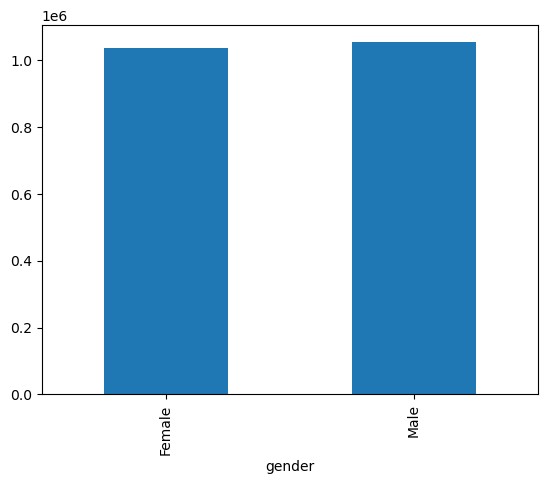

In [20]:
df.groupby('gender')['income_in_rupees'].mean().plot(kind='bar')
plt.show()

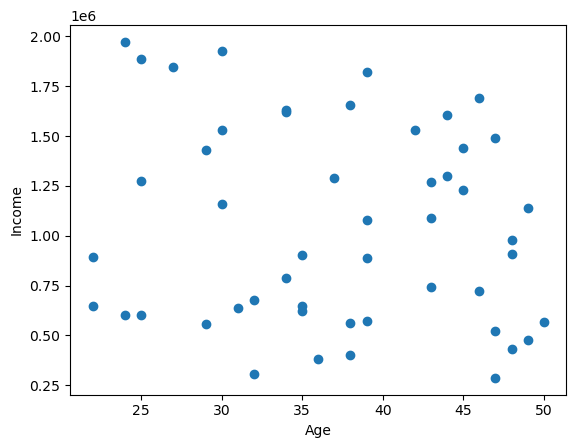

In [23]:
plt.scatter(df['age'], df['income_in_rupees'])
plt.xlabel("Age")
plt.ylabel("Income")
plt.show()

In [24]:
df.to_csv("processed_people_income.csv", index=False)